In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
  from google.colab import drive

  drive.mount('/content/drive') # load google drive
  os.chdir('/content/drive/My Drive/Thesis_Repository/Final_Google_Drive') # change directory to the current working directory

Mounted at /content/drive


## 1. Settings

In [ ]:
import json
import re
import random
import os
from pathlib import Path
from pprint import pprint

import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_auc_score,
)


from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)


FINETUNING_CONFIG_PATH = Path("./configs/finetuning__DAM__n_turns.yaml")
DATA_PATH = Path("./data/stepverify__all_turns.csv")
CHECKPOINT_OUT_DIR = "cls_model/_pretrained__DAM/all_turns/checkpoints"
MODEL_OUT_DIR = "cls_model/_pretrained__DAM/all_turns/best_model"

# MODEL_ID = "FacebookAI/roberta-base"
MODEL_ID = "./further_pretraining_model/further_pretraining__preceding_2_turn__with_speaker_info/best_model"
SEED = 42

DAM_MARGIN = 1 # margin to be used to compute AUC square loss

# Set Seed
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.mps.manual_seed(seed)
    except Exception:
        pass

set_all_seeds(SEED)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Functions to load datasets
- load dataframe
- map labels to ids
- tokenize batch
- split datasets
- build dataset objects

In [4]:
# Define tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

In [5]:
# load dataframe
def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

# map labels
def label2id_id2label(df: pd.DataFrame, show_stats: bool = True) -> dict:
    """
        map labels to integers.
        converted labels are stored in a new column called 'labels'.
    """
    label_names = sorted(df["label"].unique())

    label2id = {label: i for i, label in enumerate(label_names)}
    id2label = {i: label for label, i in label2id.items()}
    df['labels'] = df['label'].map(label2id).astype(int)

    if show_stats:
        print("[label_names]")
        print(label_names)

        print("\n[label2id]")
        print(label2id)

        print("\n[id2label]")
        print(id2label)

        print("\nEncoded label counts:")
        print(df["label"].value_counts().sort_index())
    return df, label2id, id2label

# split dataset into train, validation, and test sets ( 60:20:20 )
def split_dataset_into_train_val_test(df: pd.DataFrame, show_stats: bool = True) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED,
        stratify=df["labels"],
    )

    train_df, val_df = train_test_split(
        train_df,
        test_size=0.25,
        random_state=SEED,
        stratify=train_df["labels"],
    )

    if show_stats:
        print("[Total size]")
        print("Total:", len(df))

        print("\n[Split sizes]")
        print("train:", len(train_df))
        print("val:", len(val_df))
        print("test:", len(test_df))

        print("\n[Train label counts]")
        print(train_df["labels"].value_counts())

        print("\n[Val label counts]")
        print(val_df["labels"].value_counts())

        print("\n[Test label counts]")
        print(test_df["labels"].value_counts())

    return train_df, val_df, test_df

# tokenize batch
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        add_special_tokens=True, # include <s> and </s> tokens in the beginning and end of the text
        truncation_side="left",  # truncate from the left side
    )

# convert pandas dataframe into a Hugging Face Dataset object
def build_dataset(split_df: pd.DataFrame, tokenizer) -> Dataset:
    ds = Dataset.from_pandas(
        split_df[["text", "labels"]],
        preserve_index=False,
    )

    ds = ds.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
    )
    return ds

# Current loss function utilizes AUC for each class in the one-vs-rest manner.
# If samples of a class are not present in the train split, AUC cannot be computed. ( No positive -> TPR cannot be computed )
def check_DAM_available(train_df: pd.DataFrame, num_labels: int=4):
    # Ensure all labels exist in train split
    train_unique_labels = sorted(train_df["labels"].unique())
    expected_labels = list(range(num_labels))

    if train_unique_labels != expected_labels:
        raise ValueError(
            f"Not all classes exist the train split. "
            f"expected={expected_labels}, actual={train_unique_labels}. "
        )

## 3. Load Data

In [6]:
df = pd.read_csv(DATA_PATH)
df.head()

,text,label
0,T: tell me your solution </s> S: i think the f...,probing
1,"T: hi claire, talk me through your solution </...",focus
2,T: walk me thorugh your solution </s> S: sure....,telling
3,"T: hi deandre, talk me through your solution <...",probing
4,T: hi scott talk me through your solution </s>...,probing


## 4. Mapping Labels to Integers

In [7]:
df, label2id, id2label = label2id_id2label(df)
label_names = sorted(df["label"].unique())  # variables to use in the test result
num_labels = len(label2id) # variables to use to define a model and the test result

[label_names]
['focus', 'generic', 'probing', 'telling']

[label2id]
{'focus': 0, 'generic': 1, 'probing': 2, 'telling': 3}

[id2label]
{0: 'focus', 1: 'generic', 2: 'probing', 3: 'telling'}

Encoded label counts:
label
focus      465
generic     72
probing    407
telling     47
Name: count, dtype: int64


## 5. Split datasets into train, validation, and test sets

In [8]:
train_df, val_df, test_df = split_dataset_into_train_val_test(df)

[Total size]
Total: 991

[Split sizes]
train: 594
val: 198
test: 199

[Train label counts]
labels
0    279
2    244
1     43
3     28
Name: count, dtype: int64

[Val label counts]
labels
0    93
2    81
1    14
3    10
Name: count, dtype: int64

[Test label counts]
labels
0    93
2    82
1    15
3     9
Name: count, dtype: int64


## 6. Build Dataset Object

In [9]:
train_ds = build_dataset(train_df, tokenizer)
val_ds = build_dataset(val_df, tokenizer)
test_ds = build_dataset(test_df, tokenizer)

print("\n[Dataset columns]")
print("train:", train_ds.column_names)
print("val:", val_ds.column_names)
print("test:", test_ds.column_names)

print("\n[One tokenized example]")
print(train_ds[0].keys())
print(train_ds[0]['input_ids'])
print(tokenizer.decode(train_ds[0]['input_ids'], skip_special_tokens=False))

Map:   0%|          | 0/594 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Map:   0%|          | 0/199 [00:00<?, ? examples/s]


[Dataset columns]
train: ['labels', 'input_ids', 'attention_mask']
val: ['labels', 'input_ids', 'attention_mask']
test: ['labels', 'input_ids', 'attention_mask']

[One tokenized example]
dict_keys(['labels', 'input_ids', 'attention_mask'])
[0, 565, 35, 20280, 6, 64, 47, 3922, 110, 1948, 116, 1437, 2, 208, 35, 263, 34537, 686, 4, 939, 9658, 14, 117, 895, 2208, 26754, 13, 5, 739, 13013, 94, 353, 8, 5962, 13, 5, 650, 13013, 4, 98, 39, 746, 647, 94, 353, 21, 5594, 4, 172, 939, 9658, 14, 114, 37, 1088, 2330, 25, 203, 42, 353, 6, 37, 1088, 545, 739, 13013, 8, 290, 650, 13013, 4, 39, 746, 647, 42, 353, 74, 28, 545, 3023, 1191, 290, 3023, 389, 41383, 4, 1437, 2, 255, 35, 89, 18, 10, 203, 3013, 169, 4, 114, 47, 216, 37, 1088, 2330, 5594, 6, 141, 203, 222, 37, 1331, 42, 353, 116, 2]
<s>T: hi, can you explain your answer? </s> S: deandre sure. i calculated that noah earned 480 for the large paintings last month and 120 for the small paintings. so his total sales last month was 600. then i calcul

## 7. Define a model
7.1. define a metric function

7.2. define a Deep AUC Maximization loss class  

7.3. define a trainer
- define a model, data collator, training arguments, and a trainer that overrides the default cross entropy loss with dam loss

#### 7.1. Metric Function

In [10]:
def safe_binary_auc(y_true, y_score):
    # to compute auc, there must be both positive and negative samples
    # scikit-learn roc_auc_score uses FPR TPR to plot ROC curve and compute auc by changing the decision threshold.
    # If there is no positives -> TPR cannot be computed ( TP / TP + FN, TP + FN = 0 )
    # If there is no negatives -> FPR cannot be computed ( FP / FP + TN, FP + TN = 0 )
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if np.unique(y_true).size < 2:
        return np.nan

    return roc_auc_score(y_true, y_score)


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    logits = np.asarray(logits)
    labels = np.asarray(labels)

    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = np.argmax(probs, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "matthews_corrcoef": matthews_corrcoef(labels, preds),
    }

    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(num_labels),
        average=None,
        zero_division=0,
    )

    # one vs rest
    y_true_ovr = np.eye(num_labels, dtype=np.int64)[labels] # one-hot-encoding true labels 4x4 np.ndarray

    auc_values = []
    auc_weights = []

    for i, name in enumerate(label_names):
        label_name = str(name).replace(" ", "_")
        metrics[f"precision_{label_name}"] = float(per_class_precision[i])
        metrics[f"recall_{label_name}"] = float(per_class_recall[i])
        metrics[f"f1_{label_name}"] = float(per_class_f1[i])
        metrics[f"support_{label_name}"] = int(per_class_support[i])

        auc_i = safe_binary_auc(y_true_ovr[:, i], probs[:, i]) # compute auc for each class
        metrics[f"auc_{label_name}"] = float(auc_i) if not np.isnan(auc_i) else np.nan

        if not np.isnan(auc_i):
            auc_values.append(float(auc_i))
            auc_weights.append(int(per_class_support[i]))

    metrics["auc_macro_ovr"] = float(np.mean(auc_values)) if auc_values else np.nan  #

    return metrics


#### 7.2. Define a Deep AUC Maximization Loss class
[Robust Educational Dialogue Act Classifiers with Low-Resource and Imbalanced Datasets (Lin et al., 2023)](https://arxiv.org/pdf/2304.07499)
> ( AUC description, what it does, how it works, etc. ). Cross Entory loss function often tends to prioritize accuracy on the majority class and neglects the minority classes. It aggregates performance over all decision thresholds, measuring separability rather than accuracy at one fixed threshold. The definition of AUC is often described as equivalent to Wilcoxon-Mann-Whitney statistic ( $AUC(w) = Pr(H_w(x^+) \ge h_w(x^{-})|y=1, y'=-1 )$, [Yuan et al. (2021)](https://arxiv.org/pdf/2012.03173) ). It can be interpreted as a probability that model assigns a higher score to positive samples over negative samples among randomly selected samples. Many researches(https://openreview.net/pdf?id=gPvB4pdu_Z, https://arxiv.org/pdf/2212.04800, https://arxiv.org/html/2402.05400v1) emphsizes that in the imbalanced settings. To maximize the AUC, one needs a surrogate loss that can be interpreted as a method to maximize AUC. One of surrogate loss candidates that is widely used is "AUC square loss [Gao & Zhou (2015)](https://arxiv.org/pdf/1208.0645)". The proposed method by Gao & Zhou (2015) is used as baseline in many papers. For example, [Yuan et al. (2021)](https://arxiv.org/pdf/2012.03173) extended the formula to mitigate adverse effects on the easy examples(clear boundary) and noisy data.

> Especially, in the educational tutoring sessions, [Lin et al. (2023)](https://arxiv.org/pdf/2304.07499) showed that such approach improved the model performance in the imbalance and low-resource settings. Lin et al. (2023) ... ```< their experiment and results come here. >```. As a baseline compared to previous weighted CE loss, the model was first trained using AUC square loss ( Gao \& Zhou (2015) ). ```< experiment settings.... >```. AUC suqare loss is then extended to multi label settings. For each batch, the loss is calculated per class in each batch and summed up. The final loss is then divided by the number of classes that appeared in the batch to get the average loss across the classes.

 To maximize the effect of the AUC square loss, the model is trained in a way that maximizes ROC-AUC score defined in Scikit-learn package(https://arxiv.org/pdf/2212.04800, [Yuan et al. (2021)](https://arxiv.org/pdf/2012.03173) ).



> 후에 주석 확인.
<!-- > The paper follows AUC margin loss introduced by [Yean et al. (2021)](https://arxiv.org/pdf/2012.03173). The author describes AUC Maximization problem as equivalent to Wilcoxon-Mann-Whitney statistic(see the paper). The authors proposed modified approach AUC margin loss in the form of squared hinge loss. Its modified version for the multiclass problems are used by Lin et al. (2023), which is described below. The following function is the implementation of this loss. -> Lin et al. used AUC square loss instead of AUC margin loss (Yuan et al. (2021) -->

<!-- https://docs.libauc.org/api/libauc.losses.html#libauc.losses.auc.MultiLabelAUCMLoss -->




$$ \text{AUC square loss ( Gao & Zhou (2015) } = L_{\mathrm{batch}}=\sum_{c\in\mathcal{A}}\frac{1}{|P_c||N_c|}\sum_{i\in P_c}\sum_{j\in N_c}\left[m-\sigma(z_{i,c})+\sigma(z_{j,c})\right]_{+}^{2}$$

- Lin et al. (2023) summed up the AUC square loss across all categories instead of averaging the sum.
- $z_{i,c}$: RoBERTa logit for class $c$ of the $i$-th sample
- $\sigma(\cdot)$: sigmoid function

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

- $P_c$: set of indices of positive samples for class $c$

$$
P_c = \{i \mid y_i = c\}
$$

- $N_c$: set of indices of negative samples for class $c$

$$
N_c = \{j \mid y_j \neq c\}
$$

- $m$: margin (in this notebook, $m=1$)
- $[x]_+$: positive-part function

$$
[x]_+ = \max(0, x)
$$

- $\mathcal{A}$: set of classes in the current mini-batch that have both positive and negative samples

$$
\mathcal{A}
=
\left\{
c
\;\middle|\;
|P_c| > 0
\text{ and }
|N_c| > 0
\right\}
$$

In [11]:
class MultiClassDAMLoss(nn.Module):
    """
        This function implement DAM surrogate loss for the Trainer setup.
        - Onve-vs-rest DAM per class
        - Batchwise pairwise squared-hinge margin loss as in the paper
    """
    def __init__(self, num_classes: int, margin: float = 1.0, class_reduction: str = "sum"):
        super().__init__()
        self.num_classes = int(num_classes)
        self.margin = float(margin)
        self.class_reduction = class_reduction

    def forward(self, logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        if logits.ndim == 1: # logits -> usually has a shape of [batch size, num classes]
            logits = logits.unsqueeze(-1) # if logits has a shape of [batch size], convert it to [batch size, 1] to be compatible with the following code

        scores = torch.sigmoid(logits.float()) # [batch size, num classes], convert logits to scores ( 0 < score < 1 )

        total_loss = logits.sum() * 0.0 # container for sum of AUC square loss for each class / set total loss as the same type of logits (device, dtype) instead of integer 0.
        active_classes = 0 # count of classes that were used to compute loss ( that appeared in the batch )

        for class_idx in range(self.num_classes):
            pos_mask = labels == class_idx # ex) [0, 1, 2, 1, 3] == 0 -> [True, False, False, False, False], broadcasting
            neg_mask = labels != class_idx # ex) [0, 1, 2, 1, 3] != 0 -> [False, True, True, True, True]

            if pos_mask.sum() == 0 or neg_mask.sum() == 0: # if there is no positive or negative samples, it is not possible to compute AUC ( FPR, TPR = 0 ), also
                continue

            pos_scores = scores[pos_mask, class_idx] # [batch size, num classes] -> [num positive samples]
            neg_scores = scores[neg_mask, class_idx] # [batch size, num classes] -> [num negative samples]

            pairwise_margin = self.margin - pos_scores[:, None] + neg_scores[None, :] # 1-[1, num positive samples] + [num negative samples, 1] -> [num positive samples, num negative samples] / broadcasting, pairwise margin calculation
            class_loss = pairwise_margin.clamp_min(0.0).pow(2).mean() # max(0, mean(pairwise margin^2))

            total_loss = total_loss + class_loss
            active_classes += 1

        if active_classes == 0:
            return total_loss


        if self.class_reduction == "mean":
            return total_loss / active_classes
        if self.class_reduction == "sum": # default. Lin et al. (2023) used this.
            return total_loss

## 7.3. Define a trainer

In [12]:
# load config for training arguments
with FINETUNING_CONFIG_PATH.open("r", encoding="utf-8") as f:
  config = yaml.safe_load(f)

print("[training arguments]")
pprint( config["training_args"], sort_dicts=False, width=100, indent=2)

[training arguments]
{ 'learning_rate': 2e-05,
  'num_train_epochs': 10,
  'warmup_ratio': 0.1,
  'weight_decay': 0.01,
  'per_device_train_batch_size': 16,
  'per_device_eval_batch_size': 16,
  'eval_strategy': 'epoch',
  'save_strategy': 'epoch',
  'load_best_model_at_end': True,
  'metric_for_best_model': 'auc_macro_ovr',
  'greater_is_better': True,
  'logging_strategy': 'steps',
  'logging_steps': 10,
  'report_to': 'none'}


In [13]:
# define a model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

# define data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: ./further_pretraining_model/further_pretraining__all_turns__with_speaker_info/best_model
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
# define training arguments
training_args = TrainingArguments(
    output_dir=CHECKPOINT_OUT_DIR,
    seed=SEED,
    **config["training_args"],
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [15]:
# define a trainer that overrides the default cross entropy loss with dam loss
dam_loss_fn = MultiClassDAMLoss(
    num_classes=num_labels,
    margin=DAM_MARGIN if DAM_MARGIN is not None else 1.0,
    class_reduction="sum", # Lin et al. (2023)
)

class DAMTrainer(Trainer):
    def __init__(self, *args, dam_loss_fn=None, **kwargs):
        super().__init__(*args, **kwargs)
        if dam_loss_fn is None:
            raise ValueError("dam_loss_fn must be provided.")
        self.dam_loss_fn = dam_loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").long()
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.dam_loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [16]:
trainer = DAMTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    dam_loss_fn=dam_loss_fn,
)

## 8. Train the model

In [17]:
train_result = trainer.train()

print("\n[Train result]")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Matthews Corrcoef,Precision Focus,Recall Focus,F1 Focus,Support Focus,Auc Focus,Precision Generic,Recall Generic,F1 Generic,Support Generic,Auc Generic,Precision Probing,Recall Probing,F1 Probing,Support Probing,Auc Probing,Precision Telling,Recall Telling,F1 Telling,Support Telling,Auc Telling,Auc Macro Ovr
1,3.289487,3.525475,0.469697,0.117424,0.250000,0.159794,0.000000,0.469697,1.000000,0.639175,93,0.643011,0.000000,0.000000,0.000000,14,0.623059,0.000000,0.000000,0.000000,81,0.606732,0.000000,0.000000,0.000000,10,0.860638,0.683360
2,3.250947,3.392077,0.550505,0.277174,0.314118,0.293063,0.206522,0.608696,0.602151,0.605405,93,0.687148,0.000000,0.000000,0.000000,14,0.596273,0.500000,0.654321,0.566845,81,0.673631,0.000000,0.000000,0.000000,10,0.887766,0.711205
3,2.652159,3.014570,0.565657,0.296346,0.312226,0.282732,0.241088,0.549020,0.903226,0.682927,93,0.728213,0.000000,0.000000,0.000000,14,0.587345,0.636364,0.345679,0.448000,81,0.665823,0.000000,0.000000,0.000000,10,0.841489,0.705717
4,2.781699,2.795297,0.616162,0.433689,0.415601,0.417610,0.330452,0.650485,0.720430,0.683673,93,0.734562,0.000000,0.000000,0.000000,14,0.594332,0.584270,0.641975,0.611765,81,0.676480,0.500000,0.300000,0.375000,10,0.897872,0.725812
5,2.032353,2.617492,0.606061,0.439292,0.424970,0.407834,0.350944,0.588652,0.892473,0.709402,93,0.748182,0.000000,0.000000,0.000000,14,0.602484,0.804878,0.407407,0.540984,81,0.708241,0.363636,0.400000,0.380952,10,0.896809,0.738929
6,1.197472,2.621891,0.590909,0.385783,0.373875,0.366890,0.311505,0.595420,0.838710,0.696429,93,0.754941,0.000000,0.000000,0.000000,14,0.602873,0.725490,0.456790,0.560606,81,0.734832,0.222222,0.200000,0.210526,10,0.891489,0.746034
7,1.066406,2.601285,0.590909,0.418853,0.370715,0.377932,0.305838,0.635514,0.731183,0.680000,93,0.737430,0.071429,0.071429,0.071429,14,0.616071,0.635135,0.580247,0.606452,81,0.733565,0.333333,0.100000,0.153846,10,0.899468,0.746634
8,0.780024,2.513686,0.641414,0.516667,0.470480,0.481169,0.390520,0.619048,0.838710,0.712329,93,0.750128,0.000000,0.000000,0.000000,14,0.625776,0.733333,0.543210,0.624113,81,0.751609,0.714286,0.500000,0.588235,10,0.899468,0.756745
9,0.585432,2.595554,0.611111,0.362089,0.361545,0.353340,0.319680,0.632075,0.720430,0.673367,93,0.740809,0.200000,0.071429,0.105263,14,0.573370,0.616279,0.654321,0.634731,81,0.755513,0.000000,0.000000,0.000000,10,0.895213,0.741226
10,0.650530,2.536886,0.646465,0.478083,0.401479,0.408672,0.385222,0.644068,0.817204,0.720379,93,0.749923,0.250000,0.071429,0.111111,14,0.575311,0.684932,0.617284,0.649351,81,0.762372,0.333333,0.100000,0.153846,10,0.894149,0.745439


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[Train result]
TrainOutput(global_step=380, training_loss=1.8356056928634643, metrics={'train_runtime': 354.4257, 'train_samples_per_second': 16.76, 'train_steps_per_second': 1.072, 'total_flos': 636796716613200.0, 'train_loss': 1.8356056928634643, 'epoch': 10.0})


## 9. Test Evaluation

In [18]:
test_output = trainer.predict(test_ds)

test_logits = np.asarray(test_output.predictions)
test_probs = 1.0 / (1.0 + np.exp(-test_logits))
test_pred = np.argmax(test_probs, axis=-1)
test_true = np.asarray(test_output.label_ids)


print("\n[test classification report]")
print(
    classification_report(
        test_true,
        test_pred,
        labels=np.arange(num_labels),
        target_names=label_names,
        zero_division=0,
    )
)

print("\n[test support]")
print(
    pd.DataFrame(
        {
            "label": label_names,
            "support": [(test_true == i).sum() for i in range(num_labels)],
        }
    )
)

print("\ntest_accuracy =", round(accuracy_score(test_true, test_pred), 4))
print("test_macro_f1 =", round(f1_score(test_true, test_pred, average="macro"), 4))

print("\n[test matthews_corrcoef]")
print(matthews_corrcoef(test_true, test_pred))



y_true_ovr = np.eye(num_labels, dtype=np.int64)[test_true]
test_auc_per_class = {}
valid_auc = []

for i, name in enumerate(label_names):
    auc_i = safe_binary_auc(y_true_ovr[:, i], test_probs[:, i])
    test_auc_per_class[name] = auc_i
    if not np.isnan(auc_i):
        valid_auc.append(auc_i)

print("\n[test per-class auc]")
for name, auc_i in test_auc_per_class.items():
    print(name, "=", None if np.isnan(auc_i) else round(float(auc_i), 4))

print("\ntest_auc_macro_ovr =", None if not valid_auc else round(float(np.mean(valid_auc)), 4))




[test classification report]
              precision    recall  f1-score   support

       focus       0.59      0.81      0.68        93
     generic       0.50      0.07      0.12        15
     probing       0.64      0.50      0.56        82
     telling       0.33      0.22      0.27         9

    accuracy                           0.60       199
   macro avg       0.52      0.40      0.41       199
weighted avg       0.59      0.60      0.57       199


[test support]
     label  support
0    focus       93
1  generic       15
2  probing       82
3  telling        9

test_accuracy = 0.598
test_macro_f1 = 0.4069

[test matthews_corrcoef]
0.3039924898833346

[test per-class auc]
focus = 0.7432
generic = 0.7207
probing = 0.7504
telling = 0.8018

test_auc_macro_ovr = 0.754


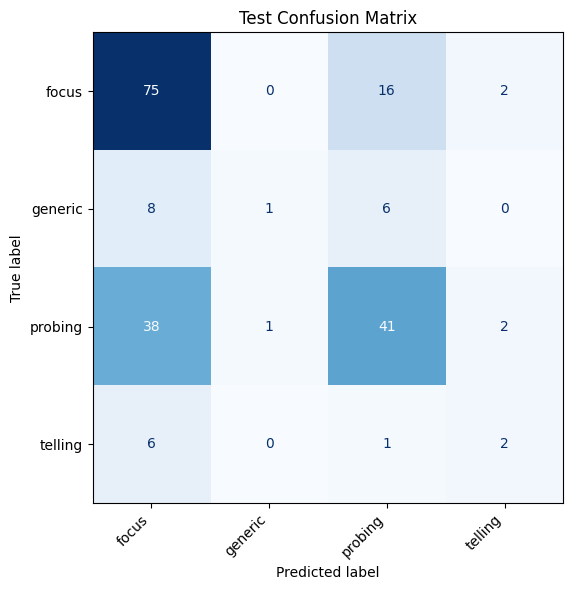

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(true_labels, pred_labels, num_labels, label_names, title="Test Confusion Matrix"):
    # Calculate confusion matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=np.arange(num_labels))

    # Visualize confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(test_true, test_pred, num_labels, label_names)

## 10. Save Model

In [20]:
trainer.save_model(MODEL_OUT_DIR)
tokenizer.save_pretrained(MODEL_OUT_DIR)

print("\nSaved model to ", MODEL_OUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved model to  cls_model/_pretrained__DAM/all_turns/best_model


## 11. Disconnect Colab Sessions (if applicable)

In [21]:
import os
import platform
import shutil
import subprocess

import psutil

def run_command(command: list[str]) -> str | None:
    try:
        result = subprocess.run(
            command,
            capture_output=True,
            text=True,
            check=True,
        )
        return result.stdout.strip()

    except (FileNotFoundError, subprocess.CalledProcessError):
        return None


def get_colab_machine_info() -> dict:
    # CPU Information
    cpu_model = run_command(
        ["bash", "-c", "lscpu | grep 'Model name' | cut -d ':' -f 2-"]
    )

    # GPU Information
    gpu_info = run_command(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,driver_version",
            "--format=csv,noheader",
        ]
    )

    # Memory and Disk Information
    memory = psutil.virtual_memory()
    disk = shutil.disk_usage("/")

    return {
        "system": platform.system(),
        "machine_architecture": platform.machine(),
        "cpu_model": cpu_model.strip() if cpu_model else "Unknown",
        "cpu_count": os.cpu_count(),
        "ram_total_gb": round(memory.total / 1024**3, 2),
        "ram_available_gb": round(memory.available / 1024**3, 2),
        "disk_total_gb": round(disk.total / 1024**3, 2),
        "disk_free_gb": round(disk.free / 1024**3, 2),
        "gpu": gpu_info or "gpu not available",
    }


In [22]:
if IN_COLAB:

  machine_info = get_colab_machine_info()

  for key, value in machine_info.items():
      print(f"{key}: {value}")

  with open("/proc/uptime", "r") as file:
    uptime_seconds = float(file.readline().split()[0])

  runtime_minutes = uptime_seconds / 60
  print(f"Current runtime: {runtime_minutes:.1f}분")

  from google.colab import runtime
  runtime.unassign()


system: Linux
machine_architecture: x86_64
cpu_model: Intel(R) Xeon(R) CPU @ 2.20GHz
cpu_count: 12
ram_total_gb: 167.05
ram_available_gb: 161.14
disk_total_gb: 235.68
disk_free_gb: 173.98
gpu: NVIDIA A100-SXM4-80GB, 81920 MiB, 580.82.07
Current runtime: 13.0분
